In [22]:
import pandas as pd

df = pd.read_csv("../data/processed/qb_combined_training.csv")

print(df.shape)
print(df.dtypes)
print(df.head())

(973, 26)
player_id                      object
player_display_name            object
season                          int64
games                           int64
overall                       float64
round                         float64
pick                          float64
height                        float64
weight                        float64
pre_draft_ranking             float64
pre_draft_position_ranking    float64
pre_draft_grade               float64
completions_pg                float64
attempts_pg                   float64
passing_yards_pg              float64
passing_tds_pg                float64
passing_interceptions_pg      float64
carries_pg                    float64
rushing_yards_pg              float64
rushing_tds_pg                float64
fumble_recovery_own_pg        float64
rushing_fumbles_lost_pg       float64
rushing_fumbles_pg            float64
target_fp_ppr                 float64
target_games                    int64
college_flag                    int64
dt

In [23]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Drop ID/tracking columns, separate target
X = df.drop(columns=["player_id","player_display_name", "season", "target_fp_ppr", "target_games"])
y = df["target_fp_ppr"]

# Stratified kfold requires a categorical stratification variable
# We'll use college_flag since that's our key grouping variable
strat = df["college_flag"]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verify fold composition
for fold, (train_idx, val_idx) in enumerate(kf.split(X, strat)):
    train_college = strat.iloc[train_idx].sum()
    val_college = strat.iloc[val_idx].sum()
    print(f"Fold {fold+1} | Train: {len(train_idx)} rows ({train_college} college) | Val: {len(val_idx)} rows ({val_college} college)")

Fold 1 | Train: 778 rows (132 college) | Val: 195 rows (34 college)
Fold 2 | Train: 778 rows (133 college) | Val: 195 rows (33 college)
Fold 3 | Train: 778 rows (133 college) | Val: 195 rows (33 college)
Fold 4 | Train: 779 rows (133 college) | Val: 194 rows (33 college)
Fold 5 | Train: 779 rows (133 college) | Val: 194 rows (33 college)


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Precompute fold indices using our stratified kfold
cv_indices = list(kf.split(X, strat))

param_grid = {
    "n_estimators": [300, 500, 750],
    "max_features": ["sqrt", 0.4, 0.6],
    "min_samples_leaf": [2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_depth": [None, 10, 20, 30]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv_indices,       # pass precomputed fold indices directly
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X, y)

print("\nBest Parameters:")
print(rf_search.best_params_)
print(f"\nBest CV RMSE: {-rf_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'n_estimators': 750, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 0.6, 'max_depth': 30}

Best CV RMSE: 5.1445


                       feature  importance
0                        games    0.398855
1             passing_yards_pg    0.098726
2                      overall    0.095574
3               completions_pg    0.074660
4       fumble_recovery_own_pg    0.061823
5                  attempts_pg    0.047287
6               passing_tds_pg    0.036869
7                        round    0.028939
8                 college_flag    0.026686
9             rushing_yards_pg    0.026525
10                  carries_pg    0.023469
11             pre_draft_grade    0.015089
12                        pick    0.012781
13    passing_interceptions_pg    0.012348
14           pre_draft_ranking    0.011600
15              rushing_tds_pg    0.008116
16          rushing_fumbles_pg    0.005725
17                      weight    0.005276
18                      height    0.003422
19  pre_draft_position_ranking    0.003179
20     rushing_fumbles_lost_pg    0.003050


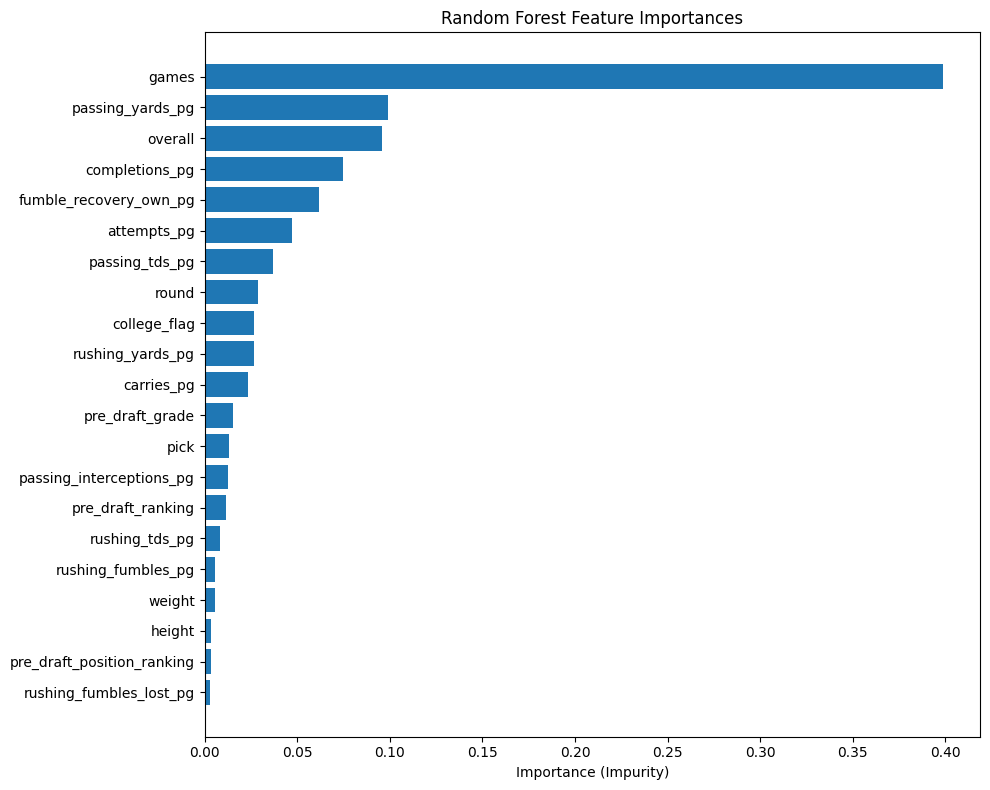

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit best model on full dataset
best_rf = rf_search.best_estimator_
best_rf.fit(X, y)

# Extract feature importances
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string())

# Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance (Impurity)")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [26]:
X_clean = X.drop(columns=["games", "fumble_recovery_own_pg"])

rf_search2 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv_indices,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search2.fit(X_clean, y)

print("\nBest Parameters:")
print(rf_search2.best_params_)
print(f"\nBest CV RMSE: {-rf_search2.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 0.6, 'max_depth': 10}

Best CV RMSE: 5.2349


                       feature  importance
0             passing_yards_pg    0.177021
1               completions_pg    0.158005
2                 college_flag    0.109069
3                      overall    0.096136
4               passing_tds_pg    0.078568
5                  attempts_pg    0.064626
6             rushing_yards_pg    0.064120
7                   carries_pg    0.043073
8     passing_interceptions_pg    0.037100
9           rushing_fumbles_pg    0.033292
10                       round    0.029445
11                        pick    0.020601
12              rushing_tds_pg    0.016699
13           pre_draft_ranking    0.015853
14                      weight    0.014321
15             pre_draft_grade    0.013315
16     rushing_fumbles_lost_pg    0.012807
17  pre_draft_position_ranking    0.008102
18                      height    0.007847


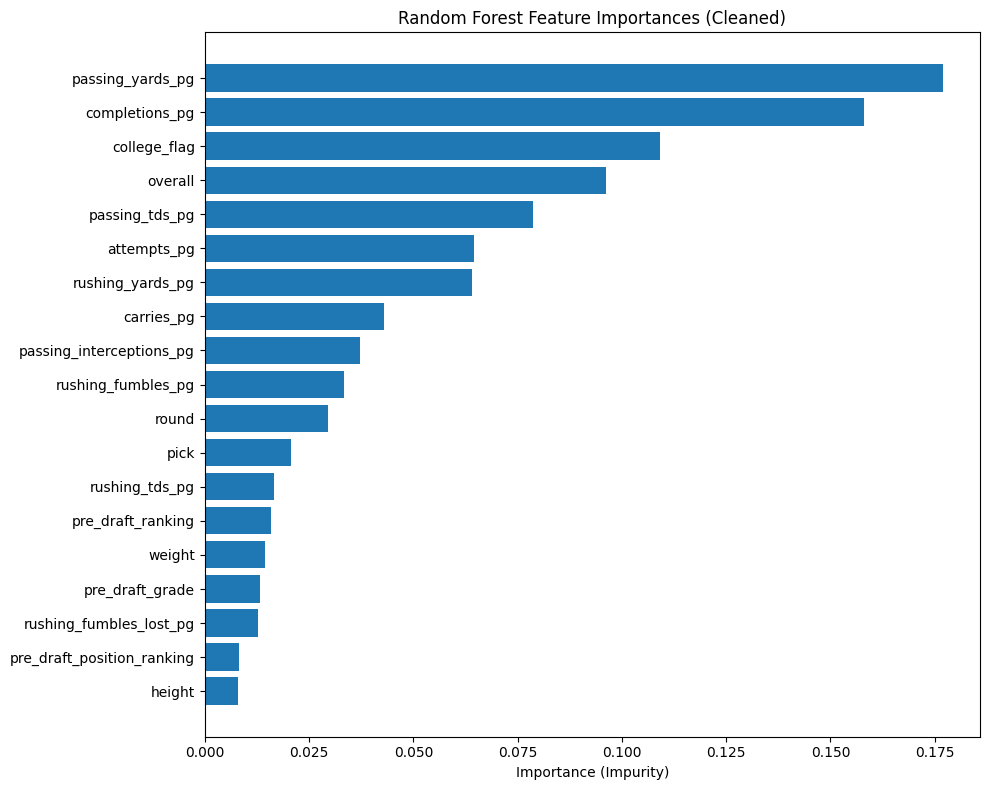

In [27]:
best_rf2 = rf_search2.best_estimator_
best_rf2.fit(X_clean, y)

importance_df2 = pd.DataFrame({
    "feature": X_clean.columns,
    "importance": best_rf2.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(importance_df2.to_string())

plt.figure(figsize=(10, 8))
plt.barh(importance_df2["feature"][::-1], importance_df2["importance"][::-1])
plt.xlabel("Importance (Impurity)")
plt.title("Random Forest Feature Importances (Cleaned)")
plt.tight_layout()
plt.show()

In [28]:
from xgboost import XGBRegressor

xgb_param_grid = {
    "n_estimators": [300, 500, 750],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=cv_indices,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_clean, y)

print("\nBest Parameters:")
print(xgb_search.best_params_)
print(f"\nBest CV RMSE: {xgb_search.best_score_ * -1:.4f}")

# Direct comparison
print(f"\n--- Model Comparison ---")
print(f"Random Forest RMSE: {-rf_search2.best_score_:.4f}")
print(f"XGBoost RMSE:       {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 20, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Best CV RMSE: 5.2606

--- Model Comparison ---
Random Forest RMSE: 5.2349
XGBoost RMSE:       5.2606


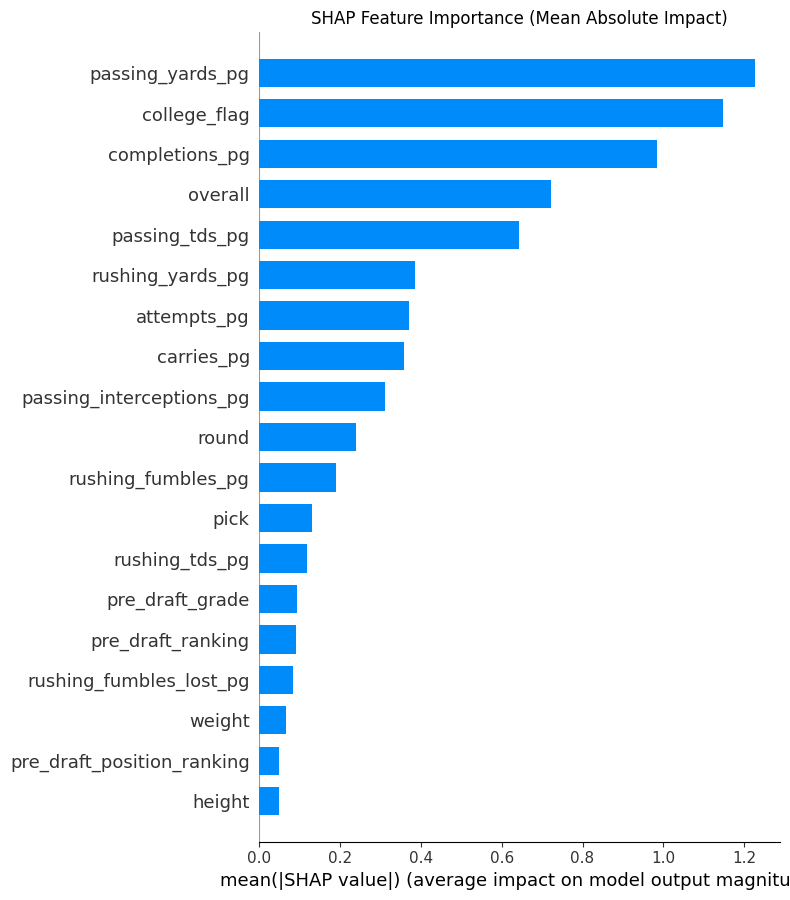

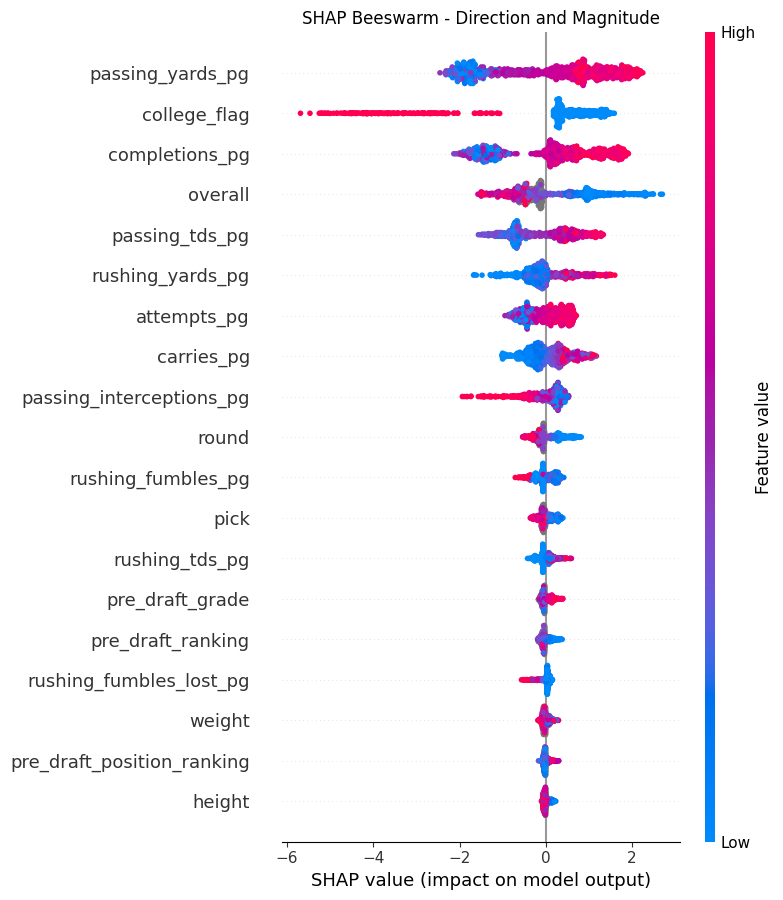

In [29]:
import shap

# Build SHAP explainer
explainer = shap.TreeExplainer(best_rf2)
shap_values = explainer.shap_values(X_clean)

# Summary plot - shows direction and magnitude for all features
shap.summary_plot(shap_values, X_clean, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean Absolute Impact)")
plt.tight_layout()
plt.show()

# Beeswarm plot - shows direction of each feature's effect
shap.summary_plot(shap_values, X_clean, show=False)
plt.title("SHAP Beeswarm - Direction and Magnitude")
plt.tight_layout()
plt.show()

In [21]:
import joblib
import json

# Save the trained RF model
joblib.dump(best_rf2, "best_rf_qb_model.joblib")

# Save the feature list so the prediction pipeline uses exact same columns
feature_cols = X_clean.columns.tolist()
with open("rf_feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print("Model saved: best_rf_qb_model.joblib")
print("Features saved: rf_feature_cols.json")
print(f"Feature count: {len(feature_cols)}")
print("Features:", feature_cols)

Model saved: best_rf_qb_model.joblib
Features saved: rf_feature_cols.json
Feature count: 19
Features: ['overall', 'round', 'pick', 'height', 'weight', 'pre_draft_ranking', 'pre_draft_position_ranking', 'pre_draft_grade', 'completions_pg', 'attempts_pg', 'passing_yards_pg', 'passing_tds_pg', 'passing_interceptions_pg', 'carries_pg', 'rushing_yards_pg', 'rushing_tds_pg', 'rushing_fumbles_lost_pg', 'rushing_fumbles_pg', 'college_flag']
